<a href="https://colab.research.google.com/github/Thanjaivalavan/M2-GenAI-AgenticAI/blob/main/AlexNet_DL_imagePredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
from torchvision import models, transforms
from PIL import Image

In [ ]:
model = models.alexnet(weights="DEFAULT")
model.eval()

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 134MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
image = Image.open("your_image.jpg").convert("RGB")

x = transform(image)
x = x.unsqueeze(0)

NameError: name 'Image' is not defined

In [ ]:
from PIL import Image

In [ ]:
print(Image)

<module 'PIL.Image' from '/usr/local/lib/python3.12/dist-packages/PIL/Image.py'>


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

NameError: name 'transforms' is not defined

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving image.jpg to image.jpg


In [ ]:
image = Image.open(list(uploaded.keys())[0]).convert("RGB")

x = transform(image)
x = x.unsqueeze(0)

print(x.shape)

NameError: name 'transform' is not defined

In [ ]:
image = Image.open(list(uploaded.keys())[0]).convert("RGB")

x = transform(image)
x = x.unsqueeze(0)

print(x.shape)

NameError: name 'transform' is not defined

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
image = Image.open(list(uploaded.keys())[0]).convert("RGB")

x = transform(image)
x = x.unsqueeze(0)

print(x.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
model = models.alexnet(weights="DEFAULT")
model.eval()

with torch.no_grad():
    output = model(x)

prediction = output.argmax(dim=1)

print("Predicted class index:", prediction.item())

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 127MB/s]


Predicted class index: 906


In [ ]:
import urllib.request

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

classes = urllib.request.urlopen(url).read().decode().splitlines()

print("Prediction:", classes[prediction.item()])

Prediction: Windsor tie


In [ ]:
probabilities = torch.softmax(output, dim=1)

confidence, predicted_index = torch.max(probabilities, dim=1)

print("Prediction:", classes[predicted_index.item()])
print("Confidence:", confidence.item() * 100, "%")

Prediction: Windsor tie
Confidence: 30.544668436050415 %


In [ ]:
top5_prob, top5_indices = torch.topk(probabilities, 5)

for i in range(5):
    print(
        f"{i+1}. {classes[top5_indices[0][i]]}: "
        f"{top5_prob[0][i].item()*100:.2f}%"
    )

1. Windsor tie: 30.54%
2. neck brace: 10.07%
3. lab coat: 8.85%
4. hoopskirt: 2.87%
5. hand-held computer: 2.74%


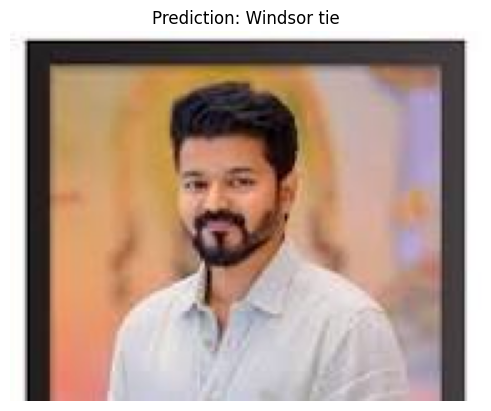

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {classes[predicted_index.item()]}"
)
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving image2.jpg to image2.jpg


In [ ]:
image = Image.open("image2.jpg").convert("RGB")

x = transform(image)
x = x.unsqueeze(0)

print(x.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
with torch.no_grad():
    output = model(x)

probabilities = torch.softmax(output, dim=1)

confidence, predicted_index = torch.max(probabilities, dim=1)

print("Prediction:", classes[predicted_index.item()])
print("Confidence:", confidence.item() * 100, "%")

Prediction: soccer ball
Confidence: 98.44212532043457 %


In [ ]:
top5_prob, top5_indices = torch.topk(probabilities, 5)

for i in range(5):
    print(
        f"{i+1}. {classes[top5_indices[0][i]]}: "
        f"{top5_prob[0][i].item()*100:.2f}%"
    )

1. soccer ball: 98.44%
2. mask: 0.65%
3. pencil sharpener: 0.30%
4. custard apple: 0.03%
5. toilet tissue: 0.03%


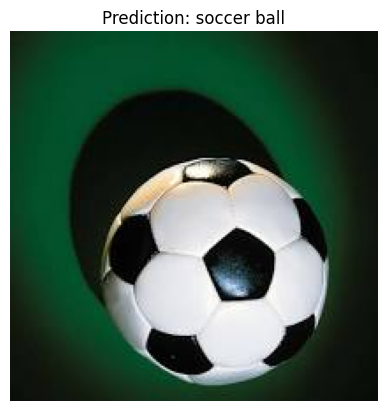

In [ ]:
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {classes[predicted_index.item()]}"
)
plt.show()